In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
from scipy.fftpack import fft, ifft, dct, idct
# plt.style.use('mplstyle')

In [2]:
# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
KK = PK21[:, 0]
PK = PK21[:, 1]

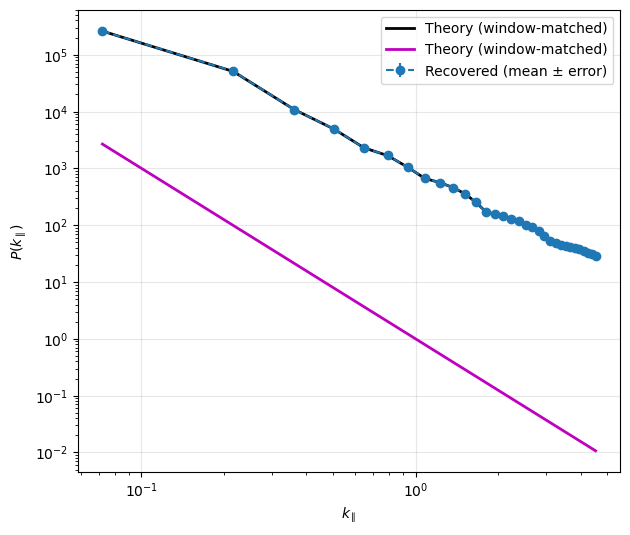

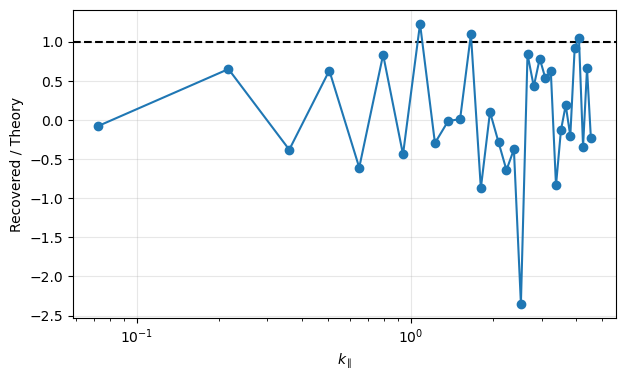

In [3]:
# ----------------------------
# Setup
# ----------------------------
n = 3.0
N = 768
dnuc = 40e-3            # MHz
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL

k_model = np.logspace(-4, 4, 5000)
P_model = k_model**(-n)

k_model = KK
P_model = PK


dx = dL

k_fft = 2*np.pi*np.arange(N)/L
# k_dct = np.pi*np.arange(N)/L # for DCT
k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model, left=0, right=0)

# correct discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont

def draw_field_from_power(P_dft):
    fk = np.zeros(N, dtype=complex)
    fk[0] = np.sqrt(P_dft[0]) * np.random.randn()
    if N % 2 == 0:
        fk[N//2] = np.sqrt(P_dft[N//2]) * np.random.randn()
    for i in range(1, N//2):
        a, b = np.random.randn(), np.random.randn()
        amp = np.sqrt(P_dft[i]/2)
        fk[i]  = amp*(a + 1j*b)
        fk[-i] = np.conjugate(fk[i])
    return np.fft.ifft(fk).real

# ----------------------------
# Realizations
# ----------------------------
# flag = np.ones(N) # pfunc.flagdata(N, mode='NOFLAG', percent = 10) # RANDOM, MWA, NOFLAG
# ml = pfunc.covtocl_fast(flag, flag) # counter for normalizition # for DCT
# w = windows.nuttall(2*N)[N:] # for DCT


Nrea = 1000
fields = np.array([pfunc.draw_field_from_power(P_dft, seed=30+i) for i in range(Nrea)])
fields = np.array([draw_field_from_power(P_dft) for _ in range(Nrea)])

pk_recovered = []

for field in fields:
    fk = np.fft.fft(field)
    pk_fft = (L / N**2) * (fk * fk.conjugate()).real
    pk_recovered.append(pk_fft)
    
    # cl = pfunc.covtocl_fast(field, field)/ml     # for DCT
    # pk_dct = dL * idct(cl.real*w, type=1) # multiply by 2 for positive modes # for DCT
    # pk_recovered.append(pk_dct) # for DCT

pk_recovered = np.array(pk_recovered)


# binning 
NB = 32  # number of bins

# Build consistent bins based on FFT k-range (skip k=0)
n1 = 0
nend = N//2
k_vals = k_abs[n1:nend]
bins = np.linspace(k_vals.min(), k_vals.max(), NB+1)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# Prepare storage
binned_rec = np.zeros((Nrea, NB))

# --- Bin each realization individually ---
for i in range(Nrea):
    for j in range(NB):
        mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
        if np.any(mask):
            binned_rec[i, j] = np.mean(pk_recovered[i, n1:nend][mask])
        else:
            binned_rec[i, j] = np.nan

# Ensemble statistics
p_rec_mean = np.nanmean(binned_rec, axis=0)
p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)

# --- Bin the theory using the same bins ---
binned_th = np.zeros(NB)
for j in range(NB):
    mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
    if np.any(mask):
        binned_th[j] = np.mean(P_cont[n1:nend][mask])
    else:
        binned_th[j] = np.nan

        
plt.figure(figsize=(7,6))
plt.errorbar(k_centers, abs(p_rec_mean), p_rec_err, fmt='o',ls='--', label='Recovered (mean ± error)')
plt.plot(k_centers, binned_th, '-k', lw=2, label='Theory (window-matched)')
plt.plot(k_centers, k_centers**(-n), '-m', lw=2, label='Theory (window-matched)')
plt.xscale('log');
plt.yscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel(r'$P(k_\parallel)$')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Ratio plot
plt.figure(figsize=(7,4))
plt.axhline(1.0, color='k', ls='--')
err = p_rec_mean / binned_th - 1
plt.plot(k_centers, 100*err, 'o-')
plt.xscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel('Recovered / Theory')
plt.grid(alpha=0.3)
plt.show()


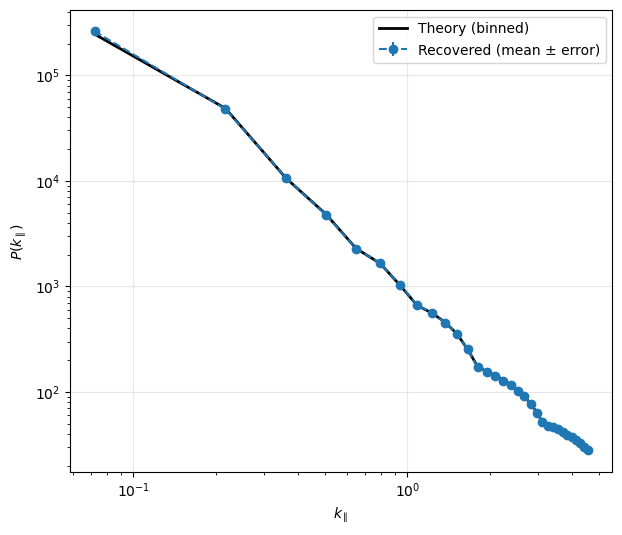

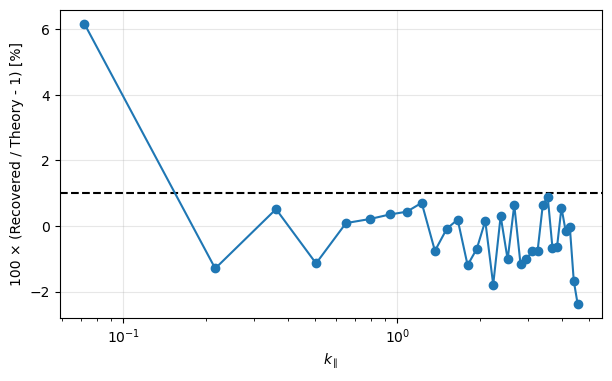

In [8]:
# ----------------------------
# Setup
# ----------------------------
n = 1.0
N = 768
dnuc = 40e-3            # MHz
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp          # Mpc per channel
L  = N * dL             # total LOS length (Mpc)

# k_model = np.logspace(-4, 4, 5000)
# P_model = k_model**(-n)

dx = dL

# FFT k-grid (used for generation)
k_fft = 2*np.pi*np.arange(N)/L
k_abs = np.abs(k_fft)

# DCT k-grid for HALF the correlation (M = N//2)
M = N # //2
k_dct = np.pi * np.arange(M) / ((M-1) * dx)   # k_n = n*pi / L_eff, L_eff = (M-1)*dx

# --- theory on FFT grid (for generation) ---
P_cont_fft = np.interp(k_abs, k_model, P_model, left=0, right=0)

# --- theory on DCT grid (for comparison to pk_dct) ---
P_cont_dct = np.interp(k_dct, k_model, P_model, left=0, right=0)

# correct discrete variance for FFT modes (used in drawing fields)
P_dft = (N**2 / L) * P_cont_fft


def draw_field_from_power(P_dft):
    fk = np.zeros(N, dtype=complex)
    fk[0] = np.sqrt(P_dft[0]) * np.random.randn()
    if N % 2 == 0:
        fk[N//2] = np.sqrt(P_dft[N//2]) * np.random.randn()
    for i in range(1, N//2):
        a, b = np.random.randn(), np.random.randn()
        amp = np.sqrt(P_dft[i]/2)
        fk[i]  = amp*(a + 1j*b)
        fk[-i] = np.conjugate(fk[i])
    return np.fft.ifft(fk).real


# ----------------------------
# Realizations
# ----------------------------
flag = np.ones(N)                       # all channels unflagged
ml = pfunc.covtocl_fast(flag, flag)     # separation counts
w_full = windows.nuttall(2*N)[N:]       # length N window for cl

Nrea = 1000
# fields = np.array([draw_field_from_power(P_dft) for _ in range(Nrea)])
fields = np.array([pfunc.draw_field_from_power(P_dft, seed=42+i) for i in range(Nrea)])

pk_recovered = []

for field in fields:
    # cl has only positive lags, length ≈ N
    cl_full = pfunc.covtocl_fast(field, field)/ml

    # Use only FIRST HALF of the correlation:
    cl = cl_full[:M]              # shape (M,)
    w  = w_full[:M]               # matching window
    w = windows.nuttall(2*M)[M:]

    # --- DCT estimator (discrete Wiener–Khinchin for half-corr, cosine basis) ---
    # P(k_n) ≈ 2 * dx * sum_{m=0}^{M-1} cl[m] cos(π m n/(M-1))
    # scipy.fft.idct(..., type=1) returns exactly that unnormalized cosine sum
    pk_dct = dx * idct(cl.real * w, type=1)

    # endpoint corrections: m=0 and m=M-1 get half-weight in the integral
    # pk_dct[0]      /= 2.0
    # pk_dct[-1]     /= 2.0

    pk_recovered.append(pk_dct)

pk_recovered = np.array(pk_recovered)   # shape (Nrea, M)


# ----------------------------
# Binning in k (DCT grid)
# ----------------------------
NB = 32  # number of bins

# choose a safe k-range away from DC/Nyquist
n1   = 0
nend = M
k_vals = k_dct[n1:nend]                # DCT k-grid in this range

bins = np.linspace(k_vals.min(), k_vals.max(), NB+1)
k_centers = 0.5 * (bins[:-1] + bins[1:])

# Prepare storage
binned_rec = np.zeros((Nrea, NB))

# --- Bin each realization individually ---
for i in range(Nrea):
    spec = pk_recovered[i, n1:nend]
    for j in range(NB):
        mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
        if np.any(mask):
            binned_rec[i, j] = np.mean(spec[mask])
        else:
            binned_rec[i, j] = np.nan

# Ensemble statistics
p_rec_mean = np.nanmean(binned_rec, axis=0)
p_rec_err  = np.nanstd(binned_rec, axis=0) / np.sqrt(Nrea)

# --- Bin the theory on the SAME k-grid (DCT) ---
binned_th = np.zeros(NB)
theory_slice = P_cont_dct[n1:nend]
for j in range(NB):
    mask = (k_vals >= bins[j]) & (k_vals < bins[j+1])
    if np.any(mask):
        binned_th[j] = np.mean(theory_slice[mask])
    else:
        binned_th[j] = np.nan


# ----------------------------
# Plots
# ----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.errorbar(k_centers, abs(p_rec_mean), p_rec_err,
             fmt='o', ls='--', label='Recovered (mean ± error)')
plt.plot(k_centers, binned_th, '-k', lw=2, label='Theory (binned)')
# plt.plot(k_centers, k_centers**(-n), '-m', lw=1, label=r'$k^{-n}$ reference')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel(r'$P(k_\parallel)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Ratio plot
plt.figure(figsize=(7,4))
plt.axhline(1.0, color='k', ls='--')
err = p_rec_mean / binned_th - 1.0
plt.plot(k_centers, 100*err, 'o-')
plt.xscale('log')
plt.xlabel(r'$k_\parallel$')
plt.ylabel('100 × (Recovered / Theory - 1) [%]')
plt.grid(alpha=0.3)
plt.show()


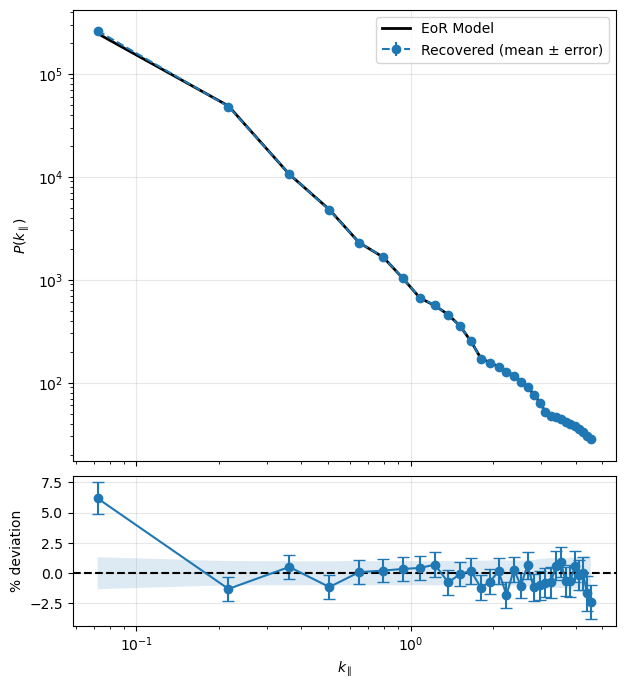

In [10]:
fig = plt.figure(figsize=(7, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

ax1 = fig.add_subplot(gs[0])

ax1.errorbar(k_centers, abs(p_rec_mean), p_rec_err, 
             fmt='o', ls='--', label='Recovered (mean ± error)')
ax1.plot(k_centers, binned_th, '-k', lw=2, label='EoR Model')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylabel(r'$P(k_\parallel)$')
ax1.legend()
ax1.grid(alpha=0.3)

ax1.tick_params(labelbottom=False)

# ---------------- Bottom panel (ratio) ----------------
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ratio = p_rec_mean / binned_th - 1               # fractional deviation
ratio_err = p_rec_err / binned_th                # fractional error bar

# Plot error bars (percentage)
ax2.errorbar(k_centers, 100*ratio, 100*ratio_err, fmt='o-', capsize=4)

# Zero line
ax2.axhline(0, color='k', ls='--')

# Shaded band around zero (±5%)
ax2.fill_between(k_centers, -100*ratio_err, 100*ratio_err, alpha=0.15)

ax2.set_xlabel(r'$k_\parallel$')
ax2.set_ylabel('% deviation')
ax2.set_xscale('log')
ax2.grid(alpha=0.3)

plt.show()

In [6]:
k_dct

array([0.        , 0.00602703, 0.01205406, 0.01808109, 0.02410813,
       0.03013516, 0.03616219, 0.04218922, 0.04821625, 0.05424328,
       0.06027031, 0.06629734, 0.07232438, 0.07835141, 0.08437844,
       0.09040547, 0.0964325 , 0.10245953, 0.10848656, 0.1145136 ,
       0.12054063, 0.12656766, 0.13259469, 0.13862172, 0.14464875,
       0.15067578, 0.15670282, 0.16272985, 0.16875688, 0.17478391,
       0.18081094, 0.18683797, 0.192865  , 0.19889203, 0.20491907,
       0.2109461 , 0.21697313, 0.22300016, 0.22902719, 0.23505422,
       0.24108125, 0.24710829, 0.25313532, 0.25916235, 0.26518938,
       0.27121641, 0.27724344, 0.28327047, 0.28929751, 0.29532454,
       0.30135157, 0.3073786 , 0.31340563, 0.31943266, 0.32545969,
       0.33148672, 0.33751376, 0.34354079, 0.34956782, 0.35559485,
       0.36162188, 0.36764891, 0.37367594, 0.37970298, 0.38573001,
       0.39175704, 0.39778407, 0.4038111 , 0.40983813, 0.41586516,
       0.4218922 , 0.42791923, 0.43394626, 0.43997329, 0.44600

In [7]:
x, y

NameError: name 'x' is not defined

In [ ]:
plt.plot(x, y)